# 🎬 TMDB Movies — Full Pipeline
## Deep Learning (RNN/LSTM/GRU/BiLSTM/BiGRU) + RAG + LLM Agent

```
┌──────────────────────────────────────────────────────────────┐
│                    AGENT SYSTEM (Tool Calling)                │
│  ┌────────────┐  ┌──────────────────┐  ┌──────────────────┐  │
│  │predict_rev │  │search_similar_   │  │explain_          │  │
│  │enue (tool) │  │movies (tool)     │  │prediction (tool) │  │
│  └─────┬──────┘  └────────┬─────────┘  └────────┬─────────┘  │
│        └─────────────────┴───────────────────────┘            │
│                            ▼                                   │
│               ┌─────────────────────┐                         │
│               │      LLM Core        │                         │
│               │ (HuggingFace Hub)    │                         │
│               └──────────┬──────────┘                         │
└──────────────────────────┼─────────────────────────────────────┘
                            ▼
           ┌─────────────────────────────┐
           │        RAG Pipeline          │
           │  FAISS / Chroma Vector Store │
           │  sentence-transformers       │
           │  all-MiniLM-L6-v2           │
           └─────────────────────────────┘
                            ▼
           ┌─────────────────────────────┐
           │     Deep Learning Models     │
           │  SimpleRNN / LSTM / GRU     │
           │  Bidirectional LSTM / GRU   │
           └─────────────────────────────┘
```

### Pipeline Steps:
1. **Data Prep** — Load & clean TMDB dataset (credits + movies)
2. **EDA** — Genre distribution, budget/revenue histograms
3. **Deep Learning** — Train 5 RNN-based models for revenue prediction
4. **Embeddings** — Embed movies using `all-MiniLM-L6-v2`
5. **Vector DB** — Store in FAISS (fast) or ChromaDB (persistent)
6. **RAG Inference** — Retrieve top-k similar movies as context
7. **LLM Layer** — Pass context to HuggingFace model for richer explanation
8. **Agent System** — Tool calling for revenue prediction, search, explanation

## 📦 0) Install Dependencies

## 📚 1) Imports & Config

In [2]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from typing import Optional

# Embeddings
from sentence_transformers import SentenceTransformer

# Vector DBs
import faiss
import chromadb
from chromadb.config import Settings

# HuggingFace Hub (بدل Anthropic)
from huggingface_hub import InferenceClient

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Bidirectional, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# ML (Gradient Boosting for Agent tool)
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

warnings.filterwarnings('ignore')

# ──────────────────────────────────────────────
# CONFIG
# ──────────────────────────────────────────────
HUGGING_FACE_HUB_TOKEN = os.getenv("HUGGING_FACE_HUB_TOKEN", "hf_YOUR_TOKEN_HERE")

EMBED_MODEL_NAME = "all-MiniLM-L6-v2"
TOP_K            = 5          # retrieve top-5 similar movies
VECTOR_BACKEND   = "faiss"    # "faiss" or "chroma"

# HuggingFace Inference model (free serverless inference)
HF_LLM_MODEL = "mistralai/Mistral-7B-Instruct-v0.3"

print("✅ Imports done")
print(f"   TensorFlow      : {tf.__version__}")
print(f"   Embedding model : {EMBED_MODEL_NAME}")
print(f"   Vector backend  : {VECTOR_BACKEND}")
print(f"   LLM (HF Hub)    : {HF_LLM_MODEL}")
print(f"   Top-K retrieval : {TOP_K}")

✅ Imports done
   TensorFlow      : 2.19.0
   Embedding model : all-MiniLM-L6-v2
   Vector backend  : faiss
   LLM (HF Hub)    : mistralai/Mistral-7B-Instruct-v0.3
   Top-K retrieval : 5


## 🎬 2) Data Preparation

In [3]:
# ── Load Data ──────────────────────────────────────────────────
credits = pd.read_csv('/kaggle/input/datasets/organizations/tmdb/tmdb-movie-metadata/tmdb_5000_credits.csv')
movies  = pd.read_csv('/kaggle/input/datasets/organizations/tmdb/tmdb-movie-metadata/tmdb_5000_movies.csv')

print('Credits shape:', credits.shape)
print('Movies shape :', movies.shape)

Credits shape: (4803, 4)
Movies shape : (4803, 20)


In [4]:
# ── Merge ──────────────────────────────────────────────────────
allmovies_df = pd.merge(left=movies, right=credits,
                        left_on='id', right_on='movie_id',
                        suffixes=('_left', '_right'))

allmovies_df.drop(['id', 'title_right'], axis=1, inplace=True)
allmovies_df = allmovies_df.rename(columns={'title_left': 'title'})

allmovies_df = allmovies_df[['movie_id','budget','title','original_title','status','tagline',
                              'release_date','runtime','genres','production_companies',
                              'production_countries','popularity','revenue','vote_average',
                              'vote_count','cast','crew','homepage','keywords',
                              'original_language','overview','spoken_languages']]
print('Merged shape:', allmovies_df.shape)

Merged shape: (4803, 22)


In [5]:
# ── Parse JSON columns ─────────────────────────────────────────
json_columns = ['genres', 'keywords', 'production_countries', 'spoken_languages']

for column in json_columns:
    allmovies_df[column] = allmovies_df[column].apply(json.loads)

allmovies_df['crew']                 = allmovies_df['crew'].apply(json.loads)
allmovies_df['cast']                 = allmovies_df['cast'].apply(json.loads)
allmovies_df['production_companies'] = allmovies_df['production_companies'].apply(json.loads)

def process_jsoncols(colname):
    return [x['name'] for x in colname]

for colname in json_columns:
    allmovies_df[colname] = allmovies_df[colname].apply(process_jsoncols)

allmovies_df['production_companies'] = allmovies_df['production_companies'].apply(process_jsoncols)

# Cast: leading actor only
for index, x in zip(allmovies_df.index, allmovies_df['cast']):
    castlist = [x[i]['name'] for i in range(len(x)) if x[i]['order'] < 1]
    allmovies_df.loc[index, 'cast'] = str(castlist)

allmovies_df['cast'] = (allmovies_df['cast'].str.strip('[]')
                                             .str.replace("'", '')
                                             .str.replace('"', '')
                                             .str.replace(' ', ''))

# Crew: director only
for index, x in zip(allmovies_df.index, allmovies_df['crew']):
    crewlist = [x[i]['name'] for i in range(len(x)) if x[i]['job'] == 'Director']
    allmovies_df.loc[index, 'crew'] = str(crewlist)

allmovies_df['crew'] = (allmovies_df['crew'].str.strip('[]')
                                             .str.replace("'", '')
                                             .str.replace('"', '')
                                             .str.replace(' ', ''))

listcols = ['genres','keywords','production_countries','production_companies','spoken_languages']
for colname in listcols:
    allmovies_df[colname] = allmovies_df[colname].apply(lambda x: ','.join(map(str, x)))

# Release date
allmovies_df['release_date']  = pd.to_datetime(allmovies_df['release_date'])
allmovies_df['release_year']  = allmovies_df['release_date'].dt.year
allmovies_df['release_month'] = allmovies_df['release_date'].dt.month

print('✅ JSON columns parsed')
allmovies_df[['title','genres','crew','cast','release_year']].head(3)

✅ JSON columns parsed


,title,genres,crew,cast,release_year
0,Avatar,"Action,Adventure,Fantasy,Science Fiction",JamesCameron,SamWorthington,2009.0
1,Pirates of the Caribbean: At World's End,"Adventure,Fantasy,Action",GoreVerbinski,JohnnyDepp,2007.0
2,Spectre,"Action,Adventure,Crime",SamMendes,DanielCraig,2015.0


## 📊 3) Exploratory Data Analysis

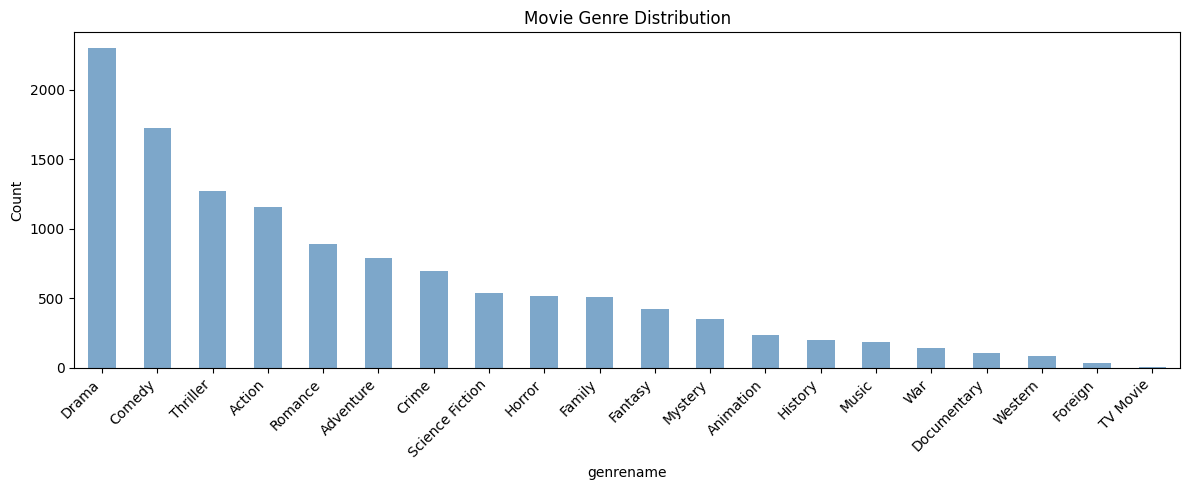

In [6]:
movies_genres = pd.DataFrame(allmovies_df[['movie_id','budget','title','release_year',
                                           'release_month','genres','revenue',
                                           'vote_average','vote_count','original_language']])

genres_list = set()
for sstr in allmovies_df['genres'].str.split(','):
    genres_list = set().union(sstr, genres_list)
genres_list = list(genres_list)
if '' in genres_list:
    genres_list.remove('')

for genre in genres_list:
    movies_genres[genre] = movies_genres['genres'].str.contains(genre).apply(lambda x: 1 if x else 0)

genre_count = [[g, movies_genres[g].values.sum()] for g in genres_list]
genre_df = pd.DataFrame(genre_count, columns=['genrename','genrecount'])
genre_df.sort_values('genrecount', ascending=False, inplace=True)

plt.figure(figsize=(12, 5))
genre_df.set_index('genrename')['genrecount'].plot.bar(color='steelblue', alpha=0.7)
plt.ylabel('Count')
plt.title('Movie Genre Distribution')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

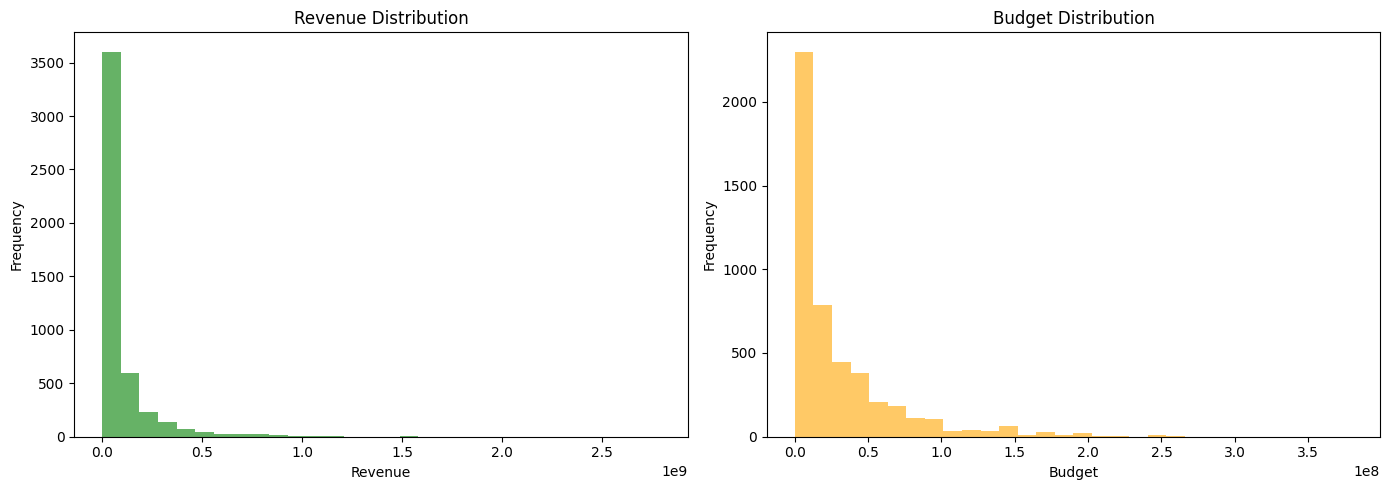

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
movies_genres['revenue'].plot.hist(ax=axes[0], bins=30, alpha=0.6, color='green')
axes[0].set_title('Revenue Distribution')
axes[0].set_xlabel('Revenue')

movies_genres['budget'].plot.hist(ax=axes[1], bins=30, alpha=0.6, color='orange')
axes[1].set_title('Budget Distribution')
axes[1].set_xlabel('Budget')
plt.tight_layout()
plt.show()

## 🤖 4) Feature Engineering for Deep Learning

In [8]:
# Remove Avatar outlier & clean
mov_g = movies_genres[movies_genres['revenue'] < 1_000_000_000].copy()
mov_g.dropna(axis=0, how='any', inplace=True)
print(f'Samples after cleaning: {len(mov_g)}')

feature_cols = ['budget','release_year','release_month','vote_average','vote_count',
                'Animation','Thriller','Family','Adventure','Western','War','Drama',
                'Action','Mystery','Science Fiction','Documentary','Foreign',
                'TV Movie','Fantasy','Music','History','Horror','Romance','Crime','Comedy']

feature_cols = [c for c in feature_cols if c in mov_g.columns]

X_raw = mov_g[feature_cols].values
y_raw = mov_g['revenue'].values.reshape(-1, 1)

print(f'Number of features: {len(feature_cols)}')

# Scale
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X_raw)
y_scaled = scaler_y.fit_transform(y_raw).ravel()

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_scaled, test_size=0.20, random_state=42
)

# Reshape for RNNs: (samples, timesteps=n_features, 1)
X_train_rnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_rnn  = X_test.reshape(X_test.shape[0],  X_test.shape[1],  1)

n_timesteps = X_train_rnn.shape[1]
n_features  = X_train_rnn.shape[2]

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'RNN input shape: {X_train_rnn.shape}  => (samples, timesteps, 1)')

Samples after cleaning: 4781
Number of features: 25
Train: (3824, 25), Test: (957, 25)
RNN input shape: (3824, 25, 1)  => (samples, timesteps, 1)


In [9]:
def evaluate_model(model_name, y_true_scaled, y_pred_scaled):
    """Inverse-transform predictions and compute metrics."""
    y_true = scaler_y.inverse_transform(y_true_scaled.reshape(-1, 1)).ravel()
    y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    print(f'\n{"="*45}')
    print(f'  {model_name}')
    print(f'{"="*45}')
    print(f'  R²   Score : {r2*100:.2f}%')
    print(f'  RMSE       : ${rmse:,.0f}')
    print(f'  MAE        : ${mae:,.0f}')
    return {'model': model_name, 'R2': round(r2*100, 2), 'RMSE': round(rmse, 2), 'MAE': round(mae, 2)}

def plot_history(history, model_name):
    plt.figure(figsize=(10, 4))
    plt.plot(history.history['loss'],     label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'{model_name} — Training History')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.legend()
    plt.tight_layout()
    plt.show()

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
results    = []

print('Helper functions ready ✔')

Helper functions ready ✔


## 🧠 5) Model 1 — SimpleRNN

I0000 00:00:1778694331.570970     153 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778694331.577273     153 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "SimpleRNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 25, 64)         │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 25, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,873 (30.75 KB)

 Trainable params: 7,873 (30.75 KB)

...

Epoch 1/100


I0000 00:00:1778694336.022722     196 service.cc:152] XLA service 0x4f1c0600 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778694336.022755     196 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778694336.022759     196 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778694336.578369     196 cuda_dnn.cc:529] Loaded cuDNN version 91002


 30/102 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1096 - mae: 0.2464

I0000 00:00:1778694338.972469     196 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


102/102 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - loss: 0.0656 - mae: 0.1770 - val_loss: 0.0149 - val_mae: 0.0709
Epoch 2/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0196 - mae: 0.0886 - val_loss: 0.0146 - val_mae: 0.0755
Epoch 3/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0163 - mae: 0.0826 - val_loss: 0.0122 - val_mae: 0.0739
Epoch 4/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0141 - mae: 0.0761 - val_loss: 0.0132 - val_mae: 0.0717
Epoch 5/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0132 - mae: 0.0738 - val_loss: 0.0117 - val_mae: 0.0674
Epoch 6/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0138 - mae: 0.0738 - val_loss: 0.0164 - val_mae: 0.0825
Epoch 7/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0132 - mae: 0.0716 - val_loss: 0.0096 - val_mae: 0.0623
Epoch 8/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0103 - mae: 0.0647 - val_loss: 0.0102 - val_mae: 0.0632
Epoch 9/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss

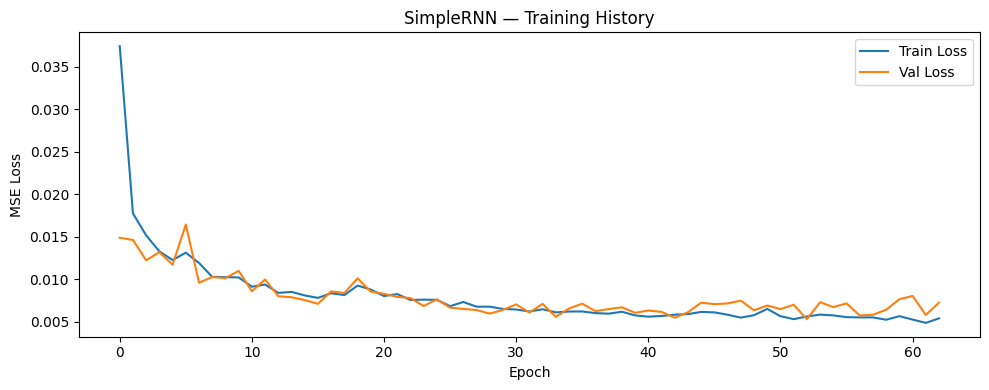

30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step 

  SimpleRNN
  R²   Score : 70.03%
  RMSE       : $85,799,437
  MAE        : $50,036,904


In [10]:
tf.random.set_seed(42)

model_rnn = Sequential([
    SimpleRNN(64, activation='tanh', return_sequences=True,
              input_shape=(n_timesteps, 1)),
    Dropout(0.2),
    SimpleRNN(32, activation='tanh'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
], name='SimpleRNN_Model')

model_rnn.compile(optimizer='adam', loss='mse', metrics=['mae'])
model_rnn.summary()

history_rnn = model_rnn.fit(
    X_train_rnn, y_train,
    epochs=100, batch_size=32,
    validation_split=0.15,
    callbacks=[early_stop], verbose=1
)

plot_history(history_rnn, 'SimpleRNN')
pred_rnn = model_rnn.predict(X_test_rnn).ravel()
results.append(evaluate_model('SimpleRNN', y_test, pred_rnn))

## 🧠 6) Model 2 — LSTM

Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 25, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 25, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0197 - mae: 0.0863 - val_loss: 0.0136 - val_mae: 0.0783
Epoch 2/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0174 - mae: 0.0803 - val_loss: 0.0127 - val_mae: 0.0732
Epoch 3/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0163 - mae: 0.0789 - val_loss: 0.0115 - val_mae: 0.0655
Epoch 4/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0162 - mae: 0.0779 - val_loss: 0.0126 - val_mae: 0.0731
Epoch 5/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0149 - mae: 0.0757 - val_loss: 0.0117 - val_mae: 0.0736
Epoch 6/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0148 - mae: 0.0773 - val_loss: 0.0114 - val_mae: 0.0722
Epoch 7/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0143 - mae: 0.0756 - val_loss: 0.0117 - val_mae: 0.0662
Epoch 8/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0148 - mae: 0.0757 - val_loss: 0.0118 - val_mae: 0.0728
Epoch 9/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms

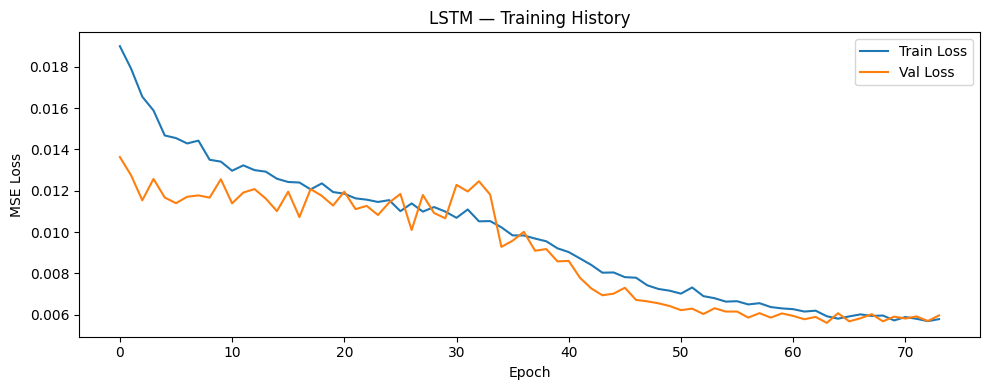

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step

  LSTM
  R²   Score : 75.05%
  RMSE       : $78,282,658
  MAE        : $46,443,759


In [11]:
tf.random.set_seed(42)

model_lstm = Sequential([
    LSTM(64, activation='tanh', return_sequences=True,
         input_shape=(n_timesteps, 1)),
    Dropout(0.2),
    LSTM(32, activation='tanh'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
], name='LSTM_Model')

model_lstm.compile(optimizer='adam', loss='mse', metrics=['mae'])
model_lstm.summary()

history_lstm = model_lstm.fit(
    X_train_rnn, y_train,
    epochs=100, batch_size=32,
    validation_split=0.15,
    callbacks=[early_stop], verbose=1
)

plot_history(history_lstm, 'LSTM')
pred_lstm = model_lstm.predict(X_test_rnn).ravel()
results.append(evaluate_model('LSTM', y_test, pred_lstm))

## 🧠 7) Model 3 — GRU

Model: "GRU_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 25, 64)         │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 25, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,817 (89.13 KB)

 Trainable params: 22,817 (89.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0207 - mae: 0.0871 - val_loss: 0.0164 - val_mae: 0.0942
Epoch 2/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0194 - mae: 0.0900 - val_loss: 0.0169 - val_mae: 0.0984
Epoch 3/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0189 - mae: 0.0877 - val_loss: 0.0176 - val_mae: 0.1004
Epoch 4/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0193 - mae: 0.0888 - val_loss: 0.0164 - val_mae: 0.0948
Epoch 5/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0186 - mae: 0.0854 - val_loss: 0.0155 - val_mae: 0.0875
Epoch 6/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0182 - mae: 0.0883 - val_loss: 0.0175 - val_mae: 0.1055
Epoch 7/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0172 - mae: 0.0837 - val_loss: 0.0124 - val_mae: 0.0763
Epoch 8/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0164 - mae: 0.0814 - val_loss: 0.0120 - val_mae: 0.0671
Epoch 9/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms

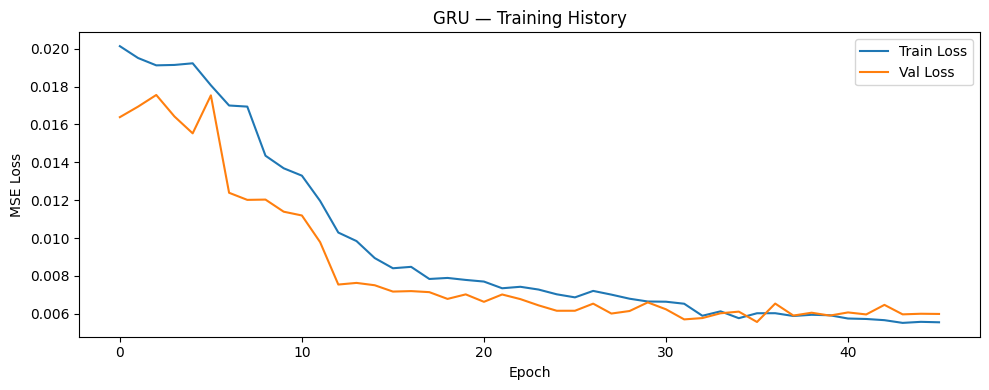

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step

  GRU
  R²   Score : 76.92%
  RMSE       : $75,300,778
  MAE        : $42,589,547


In [12]:
tf.random.set_seed(42)

model_gru = Sequential([
    GRU(64, activation='tanh', return_sequences=True,
        input_shape=(n_timesteps, 1)),
    Dropout(0.2),
    GRU(32, activation='tanh'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
], name='GRU_Model')

model_gru.compile(optimizer='adam', loss='mse', metrics=['mae'])
model_gru.summary()

history_gru = model_gru.fit(
    X_train_rnn, y_train,
    epochs=100, batch_size=32,
    validation_split=0.15,
    callbacks=[early_stop], verbose=1
)

plot_history(history_gru, 'GRU')
pred_gru = model_gru.predict(X_test_rnn).ravel()
results.append(evaluate_model('GRU', y_test, pred_gru))

## 🧠 8) Model 4a — Bidirectional LSTM

Model: "BiLSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 25, 128)        │        33,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 25, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 76,065 (297.13 KB)

 Trainable params: 76,065 (297.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
102/102 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 0.0183 - mae: 0.0846 - val_loss: 0.0128 - val_mae: 0.0794
Epoch 2/150
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0151 - mae: 0.0749 - val_loss: 0.0135 - val_mae: 0.0887
Epoch 3/150
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0141 - mae: 0.0735 - val_loss: 0.0105 - val_mae: 0.0676
Epoch 4/150
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0132 - mae: 0.0693 - val_loss: 0.0118 - val_mae: 0.0705
Epoch 5/150
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0124 - mae: 0.0670 - val_loss: 0.0108 - val_mae: 0.0622
Epoch 6/150
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0123 - mae: 0.0678 - val_loss: 0.0112 - val_mae: 0.0689
Epoch 7/150
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0113 - mae: 0.0639 - val_loss: 0.0112 - val_mae: 0.0688
Epoch 8/150
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0115 - mae: 0.0642 - val_loss: 0.0108 - val_mae: 0.0683
Epoch 9/150
102/102 ━━━━━━━━━━━━━━━━━━━━

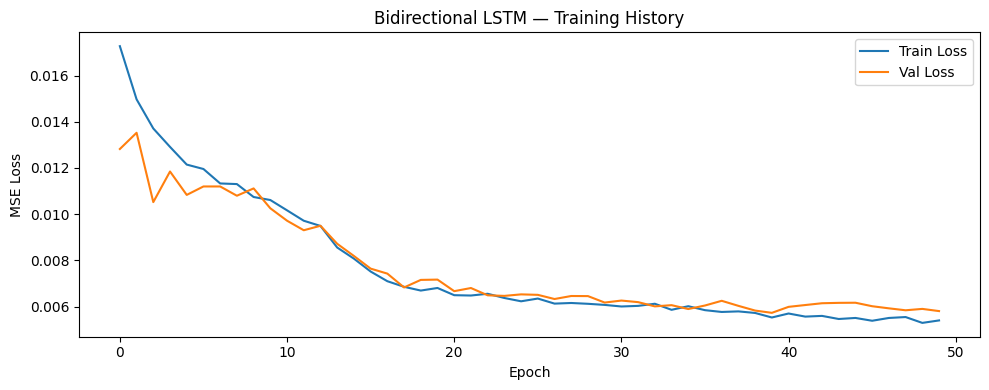

30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step

  Bidirectional LSTM
  R²   Score : 73.92%
  RMSE       : $80,039,739
  MAE        : $46,200,953


In [13]:
tf.random.set_seed(42)

model_bilstm = Sequential([
    Bidirectional(LSTM(64, activation='tanh', return_sequences=True),
                  input_shape=(n_timesteps, 1)),
    Dropout(0.2),
    Bidirectional(LSTM(32, activation='tanh')),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
], name='BiLSTM_Model')

model_bilstm.compile(optimizer='adam', loss='mse', metrics=['mae'])
model_bilstm.summary()

history_bilstm = model_bilstm.fit(
    X_train_rnn, y_train,
    epochs=150, batch_size=32,
    validation_split=0.15,
    callbacks=[early_stop], verbose=1
)

plot_history(history_bilstm, 'Bidirectional LSTM')
pred_bilstm = model_bilstm.predict(X_test_rnn).ravel()
results.append(evaluate_model('Bidirectional LSTM', y_test, pred_bilstm))

## 🧠 9) Model 4b — Bidirectional GRU

Model: "BiGRU_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_2 (Bidirectional) │ (None, 25, 128)        │        25,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 25, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 64)             │        31,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,889 (226.13 KB)

 Trainable params: 57,889 (226.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
102/102 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.0166 - mae: 0.0811 - val_loss: 0.0099 - val_mae: 0.0642
Epoch 2/150
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0112 - mae: 0.0626 - val_loss: 0.0099 - val_mae: 0.0642
Epoch 3/150
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0097 - mae: 0.0571 - val_loss: 0.0109 - val_mae: 0.0640
Epoch 4/150
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0098 - mae: 0.0567 - val_loss: 0.0101 - val_mae: 0.0604
Epoch 5/150
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0095 - mae: 0.0553 - val_loss: 0.0102 - val_mae: 0.0673
Epoch 6/150
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0091 - mae: 0.0543 - val_loss: 0.0086 - val_mae: 0.0580
Epoch 7/150
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0083 - mae: 0.0527 - val_loss: 0.0077 - val_mae: 0.0534
Epoch 8/150
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0082 - mae: 0.0522 - val_loss: 0.0074 - val_mae: 0.0545
Epoch 9/150
102/102 ━━━━━━━━━━━━━━━━━━━━

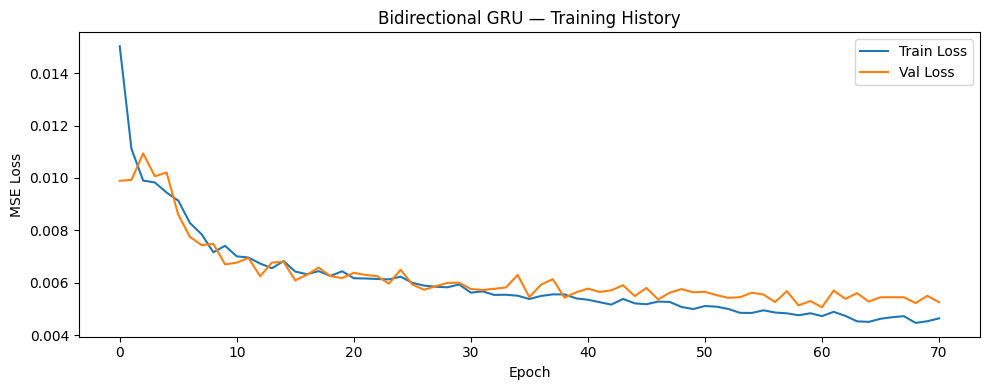

30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step

  Bidirectional GRU
  R²   Score : 76.37%
  RMSE       : $76,177,604
  MAE        : $44,960,315


In [14]:
tf.random.set_seed(42)

model_bigru = Sequential([
    Bidirectional(GRU(64, activation='tanh', return_sequences=True),
                  input_shape=(n_timesteps, 1)),
    Dropout(0.2),
    Bidirectional(GRU(32, activation='tanh')),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
], name='BiGRU_Model')

model_bigru.compile(optimizer='adam', loss='mse', metrics=['mae'])
model_bigru.summary()

history_bigru = model_bigru.fit(
    X_train_rnn, y_train,
    epochs=150, batch_size=32,
    validation_split=0.15,
    callbacks=[early_stop], verbose=1
)

plot_history(history_bigru, 'Bidirectional GRU')
pred_bigru = model_bigru.predict(X_test_rnn).ravel()
results.append(evaluate_model('Bidirectional GRU', y_test, pred_bigru))

## 📊 10) Deep Learning Models Comparison


===== Final Comparison =====
                       R2         RMSE          MAE
model                                              
SimpleRNN           70.03  85799436.52  50036903.66
LSTM                75.05  78282658.37  46443759.42
GRU                 76.92  75300777.81  42589546.80
Bidirectional LSTM  73.92  80039738.69  46200953.03
Bidirectional GRU   76.37  76177604.17  44960314.90


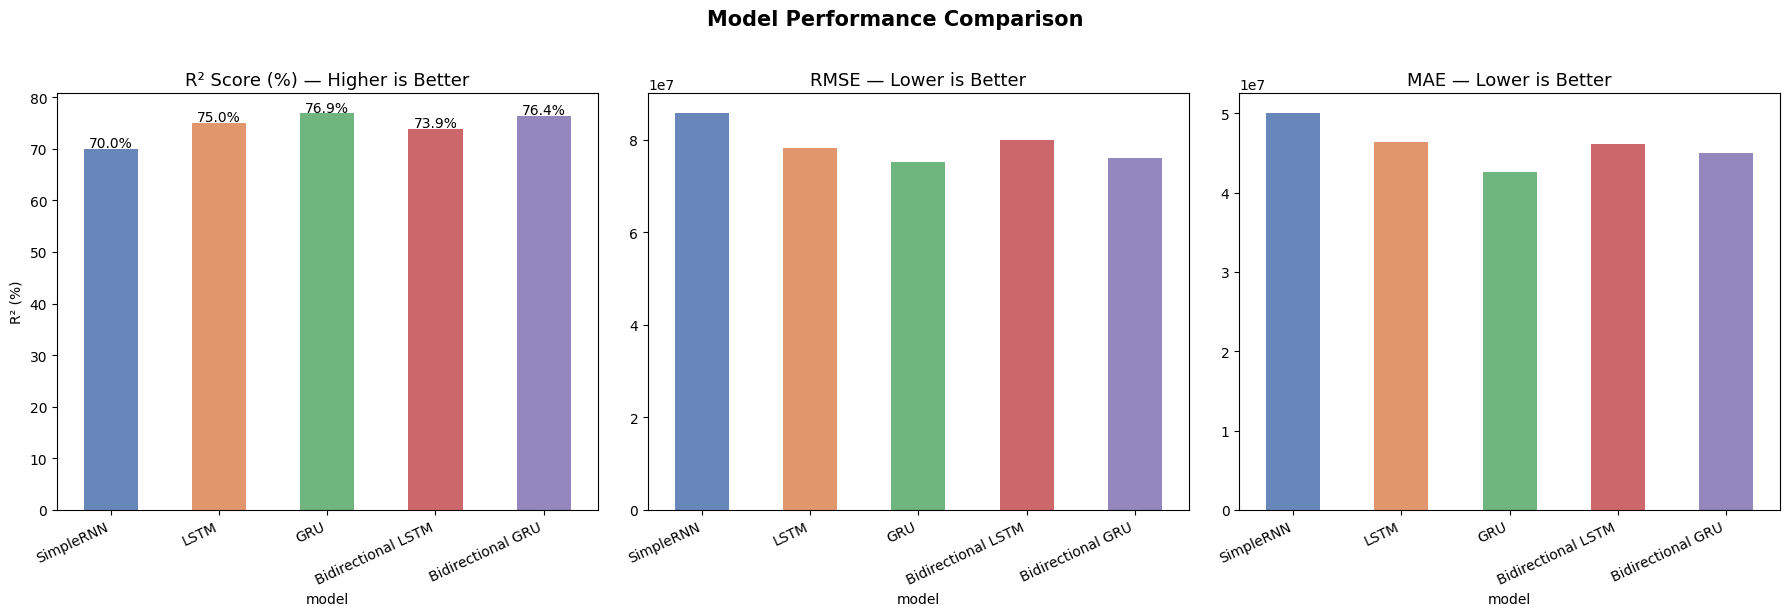

In [15]:
results_df = pd.DataFrame(results).set_index('model')
print('\n===== Final Comparison =====')
print(results_df.to_string())

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2']

results_df['R2'].plot.bar(ax=axes[0], color=colors, alpha=0.85)
axes[0].set_title('R² Score (%) — Higher is Better', fontsize=13)
axes[0].set_ylabel('R² (%)')
axes[0].set_xticklabels(results_df.index, rotation=25, ha='right')
for i, v in enumerate(results_df['R2']):
    axes[0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=10)

results_df['RMSE'].plot.bar(ax=axes[1], color=colors, alpha=0.85)
axes[1].set_title('RMSE — Lower is Better', fontsize=13)
axes[1].set_xticklabels(results_df.index, rotation=25, ha='right')

results_df['MAE'].plot.bar(ax=axes[2], color=colors, alpha=0.85)
axes[2].set_title('MAE — Lower is Better', fontsize=13)
axes[2].set_xticklabels(results_df.index, rotation=25, ha='right')

plt.suptitle('Model Performance Comparison', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

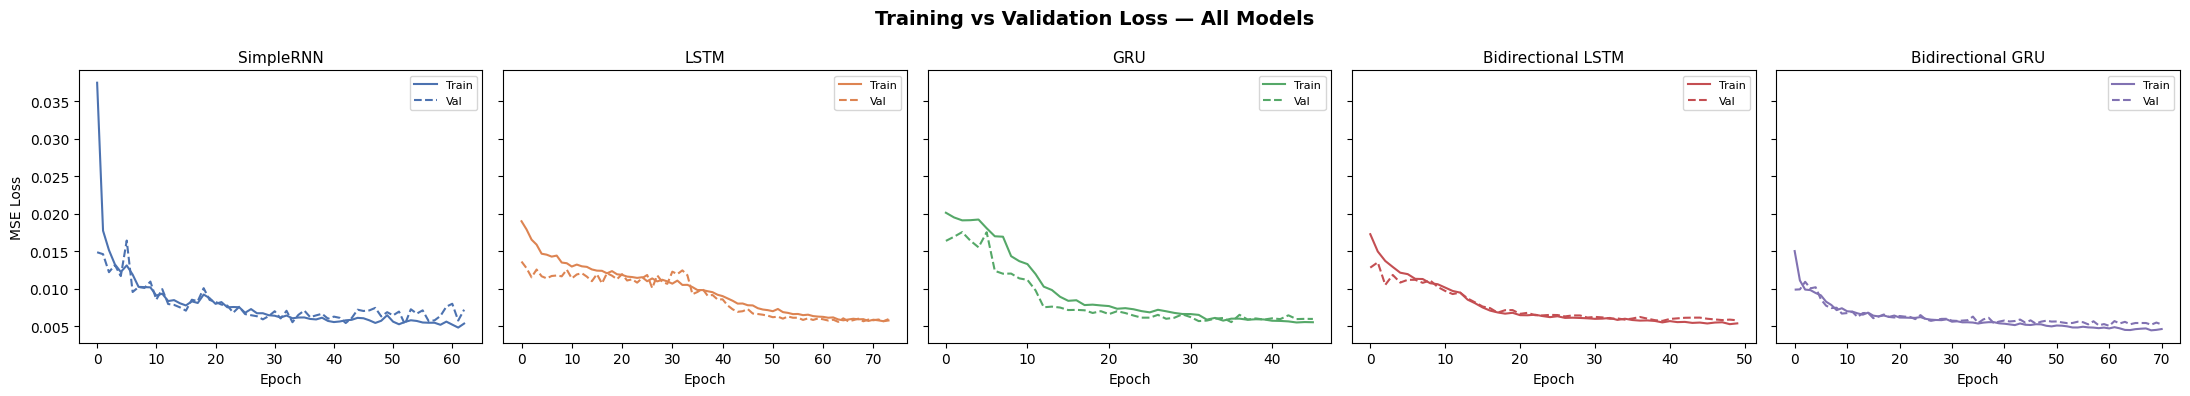

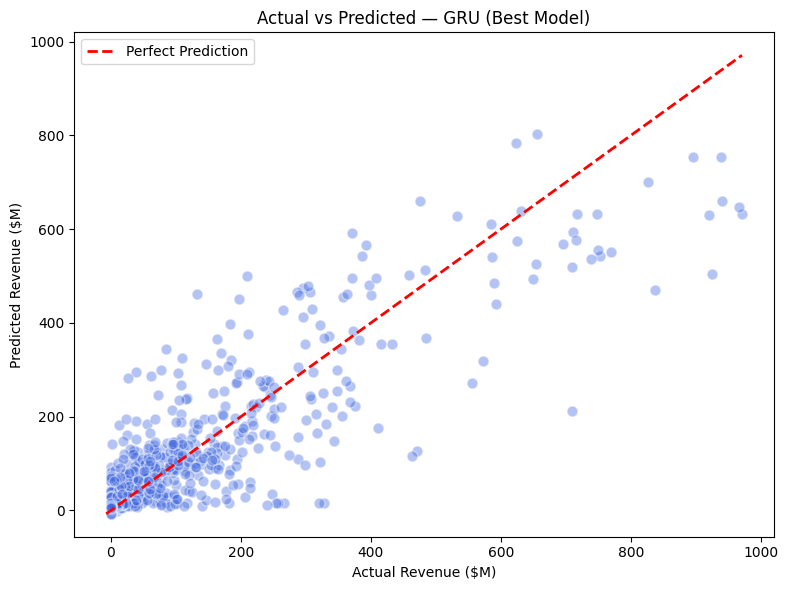


🏆 Best model: GRU  |  R² = 76.92%


In [16]:
# Loss curves all models
fig, axes = plt.subplots(1, 5, figsize=(22, 4), sharey=True)
histories = [
    (history_rnn,    'SimpleRNN',          '#4C72B0'),
    (history_lstm,   'LSTM',               '#DD8452'),
    (history_gru,    'GRU',                '#55A868'),
    (history_bilstm, 'Bidirectional LSTM', '#C44E52'),
    (history_bigru,  'Bidirectional GRU',  '#8172B2'),
]
for ax, (hist, name, color) in zip(axes, histories):
    ax.plot(hist.history['loss'],     color=color,     label='Train')
    ax.plot(hist.history['val_loss'], color=color, linestyle='--', label='Val')
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('Epoch')
    ax.legend(fontsize=8)
axes[0].set_ylabel('MSE Loss')
plt.suptitle('Training vs Validation Loss — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Best model scatter
best_model_name = results_df['R2'].idxmax()
best_pred_map = {
    'SimpleRNN': pred_rnn, 'LSTM': pred_lstm, 'GRU': pred_gru,
    'Bidirectional LSTM': pred_bilstm, 'Bidirectional GRU': pred_bigru,
}
best_pred  = best_pred_map[best_model_name]
y_true_inv = scaler_y.inverse_transform(y_test.reshape(-1, 1)).ravel()
y_pred_inv = scaler_y.inverse_transform(best_pred.reshape(-1, 1)).ravel()

plt.figure(figsize=(8, 6))
plt.scatter(y_true_inv / 1e6, y_pred_inv / 1e6, alpha=0.4, color='royalblue', edgecolors='white', s=60)
lims = [min(y_true_inv.min(), y_pred_inv.min()) / 1e6,
        max(y_true_inv.max(), y_pred_inv.max()) / 1e6]
plt.plot(lims, lims, 'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Revenue ($M)')
plt.ylabel('Predicted Revenue ($M)')
plt.title(f'Actual vs Predicted — {best_model_name} (Best Model)')
plt.legend()
plt.tight_layout()
plt.show()

print(f'\n🏆 Best model: {best_model_name}  |  R² = {results_df.loc[best_model_name, "R2"]}%')

---
## 🔢 11) Build Rich Text Representations for RAG

دلوقتي بنبدأ الجزء التاني: الـ RAG + Agent System بـ HuggingFace.

أول حاجة بنبني الـ DataFrame المنظف اللي هيتبعت للـ Vector Store.

In [17]:
# Build a clean df from allmovies_df for the RAG pipeline
def extract_names_from_str(col_str, limit=None):
    """Re-parse the stringified list columns."""
    names = [x.strip() for x in str(col_str).split(',') if x.strip()]
    return names[:limit] if limit else names

df_rag = allmovies_df.copy()
df_rag = df_rag[df_rag['revenue'] > 0].copy()
df_rag = df_rag[df_rag['budget']  > 0].copy()
df_rag.dropna(subset=['overview', 'title'], inplace=True)
df_rag.reset_index(drop=True, inplace=True)

df_rag['genres_list']   = df_rag['genres'].apply(extract_names_from_str)
df_rag['keywords_list'] = df_rag['keywords'].apply(extract_names_from_str)
df_rag['cast_list']     = df_rag['cast'].apply(lambda x: extract_names_from_str(x, limit=3))
df_rag['director']      = df_rag['crew'].apply(lambda x: extract_names_from_str(x)[0]
                                                if extract_names_from_str(x) else 'Unknown')

def build_movie_text(row) -> str:
    genres   = ', '.join(row['genres_list'])        or 'Unknown'
    keywords = ', '.join(row['keywords_list'][:8])  or 'Unknown'
    cast     = ', '.join(row['cast_list'])           or 'Unknown'
    director = row['director']
    overview = (row['overview'] or '')[:500]
    budget_m = row['budget']  / 1_000_000
    rev_m    = row['revenue'] / 1_000_000
    return (
        f"Movie: {row['title']} ({row['release_year']}).\n"
        f"Genres: {genres}.\n"
        f"Director: {director}.\n"
        f"Cast: {cast}.\n"
        f"Keywords: {keywords}.\n"
        f"Budget: ${budget_m:.1f}M. Revenue: ${rev_m:.1f}M.\n"
        f"Rating: {row['vote_average']}/10 ({row['vote_count']:,} votes).\n"
        f"Overview: {overview}"
    )

df_rag['movie_text'] = df_rag.apply(build_movie_text, axis=1)

print(f'✅ RAG dataset: {len(df_rag):,} movies')
print("\nSample movie text:")
print("─" * 60)
print(df_rag['movie_text'].iloc[0])

✅ RAG dataset: 3,229 movies

Sample movie text:
────────────────────────────────────────────────────────────
Movie: Avatar (2009.0).
Genres: Action, Adventure, Fantasy, Science Fiction.
Director: JamesCameron.
Cast: SamWorthington.
Keywords: culture clash, future, space war, space colony, society, space travel, futuristic, romance.
Budget: $237.0M. Revenue: $2788.0M.
Rating: 7.2/10 (11,800 votes).
Overview: In the 22nd century, a paraplegic Marine is dispatched to the moon Pandora on a unique mission, but becomes torn between following orders and protecting an alien civilization.


## 🔢 12) Embed Dataset with `sentence-transformers`

In [18]:
print(f'Loading embedding model: {EMBED_MODEL_NAME} ...')
embed_model = SentenceTransformer(EMBED_MODEL_NAME)

texts      = df_rag['movie_text'].tolist()
print(f'Embedding {len(texts):,} movies...')

embeddings = embed_model.encode(
    texts, batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True
)
embeddings = np.array(embeddings, dtype='float32')

print(f'\n✅ Embeddings shape: {embeddings.shape}')

Loading embedding model: all-MiniLM-L6-v2 ...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding 3,229 movies...


Batches:   0%|          | 0/51 [00:00<?, ?it/s]


✅ Embeddings shape: (3229, 384)


## 🗄️ 13) Store in Vector DB (FAISS or ChromaDB)

In [19]:
class FAISSVectorStore:
    def __init__(self, dim):
        self.index    = faiss.IndexFlatIP(dim)
        self.metadata = []
    def add(self, vecs, meta):
        self.index.add(vecs)
        self.metadata.extend(meta)
    def search(self, query_vec, k=5):
        scores, indices = self.index.search(query_vec, k)
        return [{"score": float(s), **self.metadata[i]}
                for s, i in zip(scores[0], indices[0]) if i >= 0]

class ChromaVectorStore:
    def __init__(self, collection_name='tmdb_movies'):
        self.client = chromadb.Client(Settings(anonymized_telemetry=False))
        try: self.client.delete_collection(collection_name)
        except: pass
        self.collection = self.client.create_collection(
            name=collection_name, metadata={'hnsw:space': 'cosine'})
    def add(self, vecs, meta):
        self.collection.add(
            ids=[str(m['movie_id']) for m in meta],
            embeddings=vecs.tolist(),
            documents=[m['movie_text'] for m in meta],
            metadatas=[{k: v for k, v in m.items() if k != 'movie_text'} for m in meta]
        )
    def search(self, query_vec, k=5):
        res = self.collection.query(query_embeddings=query_vec.tolist(), n_results=k,
                                    include=['metadatas','documents','distances'])
        hits = []
        for i in range(len(res['ids'][0])):
            m = res['metadatas'][0][i]
            m['movie_text'] = res['documents'][0][i]
            m['score']      = 1 - res['distances'][0][i]
            hits.append(m)
        return hits

# ── Build metadata list ────────────────────────────────────────
metadata_list = [
    {
        'movie_id'    : int(row['movie_id']),
        'title'       : str(row['title']),
        'director'    : str(row['director']),
        'genres'      : ', '.join(row['genres_list']),
        'cast'        : ', '.join(row['cast_list']),
        'budget'      : float(row['budget']),
        'revenue'     : float(row['revenue']),
        'vote_average': float(row['vote_average']),
        'vote_count'  : int(row['vote_count']),
        'release_year': int(row['release_year']),
        'movie_text'  : str(row['movie_text']),
    }
    for _, row in df_rag.iterrows()
]

if VECTOR_BACKEND == 'faiss':
    vector_store = FAISSVectorStore(dim=embeddings.shape[1])
else:
    vector_store = ChromaVectorStore()

vector_store.add(embeddings, metadata_list)
print(f'✅ Indexed {len(df_rag):,} movies into {VECTOR_BACKEND.upper()} vector store')

✅ Indexed 3,229 movies into FAISS vector store


## 🔍 14) RAG Retrieval Function

In [20]:
def retrieve_similar_movies(query: str, k: int = TOP_K):
    q_vec = embed_model.encode([query], normalize_embeddings=True).astype('float32')
    return vector_store.search(q_vec, k=k)

def format_retrieved_context(hits):
    lines = ['=== Retrieved Similar Movies (RAG Context) ===']
    for i, h in enumerate(hits, 1):
        lines.append(
            f"\n[{i}] {h['title']} ({h['release_year']})\n"
            f"    Genres  : {h['genres']}\n"
            f"    Director: {h['director']}\n"
            f"    Budget  : ${h['budget']/1e6:.1f}M\n"
            f"    Revenue : ${h['revenue']/1e6:.1f}M  "
            f"(ROI: {h['revenue']/max(h['budget'],1):.1f}x)\n"
            f"    Rating  : {h['vote_average']}/10\n"
            f"    Similarity: {h['score']:.3f}"
        )
    return '\n'.join(lines)

# Quick test
test_hits = retrieve_similar_movies('action superhero blockbuster')
print(format_retrieved_context(test_hits))

=== Retrieved Similar Movies (RAG Context) ===

[1] Batman v Superman: Dawn of Justice (2016)
    Genres  : Action, Adventure, Fantasy
    Director: ZackSnyder
    Budget  : $250.0M
    Revenue : $873.3M  (ROI: 3.5x)
    Rating  : 5.7/10
    Similarity: 0.638

[2] Super (2010)
    Genres  : Comedy, Action, Drama
    Director: JamesGunn
    Budget  : $2.5M
    Revenue : $0.3M  (ROI: 0.1x)
    Rating  : 6.6/10
    Similarity: 0.599

[3] Superman Returns (2006)
    Genres  : Adventure, Fantasy, Action, Science Fiction
    Director: BryanSinger
    Budget  : $270.0M
    Revenue : $391.1M  (ROI: 1.4x)
    Rating  : 5.4/10
    Similarity: 0.581

[4] Superhero Movie (2008)
    Genres  : Action, Comedy, Science Fiction
    Director: CraigMazin
    Budget  : $35.0M
    Revenue : $25.9M  (ROI: 0.7x)
    Rating  : 4.9/10
    Similarity: 0.580

[5] Superman IV: The Quest for Peace (1987)
    Genres  : Action, Adventure, Science Fiction
    Director: SidneyJ.Furie
    Budget  : $17.0M
    Revenue :

## 🤖 15) Train Gradient Boosting Model (for Agent Tool)

الـ Agent بيستخدم Gradient Boosting بجانب الـ Deep Learning للـ tool calling.

In [21]:
genres_dummies = df_rag['genres_list'].str.join('|').str.get_dummies()

base_feature_cols = ['budget', 'vote_average', 'vote_count', 'release_year']
X_gb = pd.concat([
    df_rag[base_feature_cols].reset_index(drop=True),
    genres_dummies.reset_index(drop=True)
], axis=1).fillna(0)

y_gb = df_rag['revenue'].values

X_gb_train, X_gb_test, y_gb_train, y_gb_test = train_test_split(
    X_gb, y_gb, test_size=0.2, random_state=42)

gb_model = GradientBoostingRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=5, random_state=42)
gb_model.fit(X_gb_train, y_gb_train)

r2_gb = r2_score(y_gb_test, gb_model.predict(X_gb_test))
print(f'✅ Gradient Boosting R² (for Agent tool): {r2_gb*100:.1f}%')

PRED_FEATURE_COLS = list(X_gb.columns)
print(f'   Features: {len(PRED_FEATURE_COLS)}')

✅ Gradient Boosting R² (for Agent tool): 75.2%
   Features: 23


## 🛠️ 16) Tool Definitions & Execution (Agent System)

الأدوات دي بتتبعت لـ HuggingFace LLM عشان يقرر يستخدم أيها.

In [22]:
TOOLS_DESCRIPTION = """
You have access to these tools. Call them by responding ONLY with a JSON object:
{"tool": "<tool_name>", "input": {<parameters>}}

Available tools:

1. predict_revenue
   - Description: Predict box-office revenue using ML model.
   - Parameters: budget (number), genres (list of strings), 
                  vote_average (number 0-10), vote_count (int), release_year (int)

2. search_similar_movies
   - Description: Semantic search in TMDB database for similar movies (RAG).
   - Parameters: query (string), k (int, default 5)

3. explain_prediction
   - Description: Generate a detailed explanation for a revenue prediction.
   - Parameters: movie_title (string), predicted_revenue (number),
                  budget (number), genres (list), similar_movies (list)

If no tool is needed, respond normally in plain text.
If you need a tool, respond ONLY with the JSON — no other text.
"""

print('✅ Tool descriptions ready')

✅ Tool descriptions ready


In [23]:
def execute_tool(tool_name: str, tool_input: dict) -> str:
    """Route tool calls from the LLM to the correct Python function."""

    if tool_name == 'predict_revenue':
        budget       = float(tool_input.get('budget', 50_000_000))
        genres       = tool_input.get('genres', [])
        vote_average = float(tool_input.get('vote_average', 6.5))
        vote_count   = int(tool_input.get('vote_count', 1000))
        release_year = int(tool_input.get('release_year', 2024))

        feat = {col: 0.0 for col in PRED_FEATURE_COLS}
        feat['budget']       = budget
        feat['vote_average'] = vote_average
        feat['vote_count']   = vote_count
        feat['release_year'] = release_year
        for g in genres:
            if g in feat:
                feat[g] = 1.0

        X_inf     = np.array([[feat[c] for c in PRED_FEATURE_COLS]])
        predicted = float(gb_model.predict(X_inf)[0])
        roi       = predicted / budget if budget > 0 else 0

        return json.dumps({
            'predicted_revenue_usd': round(predicted, 2),
            'predicted_revenue_m'  : round(predicted / 1e6, 2),
            'roi_multiplier'       : round(roi, 2),
            'success_tier': (
                'Blockbuster (>$500M)'   if predicted > 500e6 else
                'Hit ($100M–$500M)'      if predicted > 100e6 else
                'Moderate ($30M–$100M)'  if predicted > 30e6  else
                'Limited (<$30M)'
            )
        })

    elif tool_name == 'search_similar_movies':
        query = tool_input.get('query', '')
        k     = int(tool_input.get('k', TOP_K))
        hits  = retrieve_similar_movies(query, k=k)
        results = [{
            'title'        : h['title'],
            'release_year' : h['release_year'],
            'genres'       : h['genres'],
            'director'     : h['director'],
            'budget_m'     : round(h['budget']  / 1e6, 1),
            'revenue_m'    : round(h['revenue'] / 1e6, 1),
            'roi'          : round(h['revenue'] / max(h['budget'], 1), 2),
            'vote_average' : h['vote_average'],
            'similarity'   : round(h['score'], 3)
        } for h in hits]
        return json.dumps({'similar_movies': results, 'count': len(results)})

    elif tool_name == 'explain_prediction':
        movie_title   = tool_input.get('movie_title', 'Unknown')
        predicted_rev = float(tool_input.get('predicted_revenue', 0))
        budget        = float(tool_input.get('budget', 0))
        genres        = tool_input.get('genres', [])
        similar       = tool_input.get('similar_movies', [])
        avg_rev = np.mean([m.get('revenue_m', 0) for m in similar]) if similar else 0
        avg_roi = np.mean([m.get('roi', 0)       for m in similar]) if similar else 0
        best    = max(similar, key=lambda m: m.get('revenue_m', 0)) if similar else {}
        return json.dumps({
            'movie'                    : movie_title,
            'prediction'               : f'${predicted_rev/1e6:.1f}M',
            'budget'                   : f'${budget/1e6:.1f}M',
            'roi'                      : f'{predicted_rev/max(budget,1):.1f}x',
            'genre_mix'                : genres,
            'comparable_avg_revenue_m' : round(avg_rev, 1),
            'comparable_avg_roi'       : round(avg_roi, 2),
            'best_comparable'          : best.get('title', 'N/A'),
            'best_comparable_rev_m'    : best.get('revenue_m', 0),
            'key_factors'              : [
                'Budget scale (biggest predictor)',
                'Genre — Action/Adventure historically outperform',
                'Audience rating (vote_average)',
                'Release timing (summer/holiday peaks)'
            ]
        })

    else:
        return json.dumps({'error': f'Unknown tool: {tool_name}'})

print('✅ Tool executor ready')

✅ Tool executor ready


## 🤖 17) HuggingFace LLM Agent — Agentic Loop

الـ Agent بيستخدم `InferenceClient` من HuggingFace Hub بـ `HUGGING_FACE_HUB_TOKEN`.

In [29]:
# =========================================================
# HuggingFace Client Setup (Kaggle + Secrets Compatible)
# =========================================================

import json
import huggingface_hub

from kaggle_secrets import UserSecretsClient
from huggingface_hub import InferenceClient

# ---------------------------------------------------------
# Load HuggingFace Token from Kaggle Secrets
# ---------------------------------------------------------

user_secrets = UserSecretsClient()

HUGGING_FACE_HUB_TOKEN = user_secrets.get_secret(
    "HUGGING_FACE_HUB_TOKEN"
)

print("✅ HF Token Loaded")

# ---------------------------------------------------------
# Recommended Working Model
# ---------------------------------------------------------

HF_LLM_MODEL = "Qwen/Qwen2.5-7B-Instruct"

print(f"✅ Using model: {HF_LLM_MODEL}")
print(f"✅ huggingface_hub version: {huggingface_hub.__version__}")

# ---------------------------------------------------------
# Create HuggingFace Client
# ---------------------------------------------------------

hf_client = InferenceClient(
    api_key=HUGGING_FACE_HUB_TOKEN
)

# ---------------------------------------------------------
# System Prompt
# ---------------------------------------------------------

SYSTEM_PROMPT = f"""
You are a Movie Revenue Analyst specialising in box-office prediction and film industry intelligence.

You have access to a TMDB database of 5,000 movies with budgets,
revenues, genres, and ratings.

{TOOLS_DESCRIPTION}

When answering:

1. Use search_similar_movies first to retrieve historical examples (RAG).
2. Use predict_revenue for numerical revenue estimates.
3. Use explain_prediction to generate a data-backed explanation.
4. Always reference retrieved comparable movies to ground your analysis.
5. Be specific, cite numbers, and explain the reasoning.

Final answer structure:

- 🎯 Prediction summary
- 📊 Comparable movies (from RAG)
- 💡 Key insights & factors
- ⚠️ Risks & caveats
"""

# ---------------------------------------------------------
# HuggingFace LLM Call
# ---------------------------------------------------------

def call_hf_llm(messages: list, max_tokens: int = 1024) -> str:

    response = hf_client.chat.completions.create(
        model=HF_LLM_MODEL,
        messages=messages,
        max_tokens=max_tokens,
        temperature=0.3
    )

    return response.choices[0].message.content

# ---------------------------------------------------------
# Agent Loop
# ---------------------------------------------------------

def run_agent(user_question: str, verbose: bool = True) -> str:

    messages = [
        {
            "role": "system",
            "content": SYSTEM_PROMPT
        },
        {
            "role": "user",
            "content": user_question
        }
    ]

    if verbose:

        print("\n" + "=" * 60)
        print("🤖 Agent Starting")
        print("=" * 60)

    for step in range(8):

        # -------------------------------------------------
        # LLM Response
        # -------------------------------------------------

        reply = call_hf_llm(messages)

        if verbose:
            print(f"\n🧠 Step {step+1} Response:")
            print(reply[:500])

        tool_called = False

        # -------------------------------------------------
        # Try Parsing Tool Call
        # -------------------------------------------------

        try:

            clean = reply.strip()

            # Remove markdown code fences
            if clean.startswith("```"):

                clean = clean.split("```")[1]

                if clean.startswith("json"):
                    clean = clean[4:]

            parsed = json.loads(clean)

            # -------------------------------------------------
            # Tool Call Detected
            # -------------------------------------------------

            if "tool" in parsed and "input" in parsed:

                tool_name = parsed["tool"]
                tool_input = parsed["input"]

                if verbose:

                    print(f"\n🔧 Tool Call: {tool_name}")
                    print(f"📥 Input: {tool_input}")

                # Execute external tool
                result_str = execute_tool(
                    tool_name,
                    tool_input
                )

                if verbose:

                    print(f"\n📤 Tool Result:")
                    print(str(result_str)[:500])

                # Save conversation memory

                messages.append({
                    "role": "assistant",
                    "content": reply
                })

                messages.append({
                    "role": "user",
                    "content":
                        f"Tool result for {tool_name}:\n"
                        f"{result_str}\n\n"
                        f"Continue your analysis."
                })

                tool_called = True

        except Exception as e:

            if verbose:
                print(f"\n⚠️ Parsing skipped: {e}")

        # -------------------------------------------------
        # Final Response
        # -------------------------------------------------

        if not tool_called:

            if verbose:

                print(f"\n✅ Agent finished in {step+1} step(s)")

            return reply

    return "❌ Agent loop ended without final answer."

# ---------------------------------------------------------
# Quick API Test
# ---------------------------------------------------------

test = hf_client.chat.completions.create(
    model=HF_LLM_MODEL,
    messages=[
        {
            "role": "user",
            "content": "Say hello briefly."
        }
    ],
    max_tokens=20,
    temperature=0.3
)

print("\n✅ HuggingFace API Working!\n")

print(test.choices[0].message.content)

print("\n🚀 HuggingFace Agent Ready.")

✅ HF Token Loaded
✅ Using model: Qwen/Qwen2.5-7B-Instruct
✅ huggingface_hub version: 1.4.1

✅ HuggingFace API Working!

Hello! Nice to meet you.

🚀 HuggingFace Agent Ready.


## 🎯 18) Demo — Run the Agent

In [30]:
# Demo 1: Sci-fi action movie
answer = run_agent(
    "I'm planning a sci-fi action movie with a $150 million budget, "
    "similar to Interstellar and The Martian. "
    "What revenue should I expect and what similar movies should I benchmark against?",
    verbose=True
)
print("\n" + "═"*60)
print("📝 FINAL ANSWER:")
print("═"*60)
print(answer)


🤖 Agent Starting

🧠 Step 1 Response:
{"tool": "search_similar_movies", "input": {"query": "Interstellar, The Martian", "k": 5}}

🔧 Tool Call: search_similar_movies
📥 Input: {'query': 'Interstellar, The Martian', 'k': 5}

📤 Tool Result:
{"similar_movies": [{"title": "The Martian", "release_year": 2015, "genres": "Drama, Adventure, Science Fiction", "director": "RidleyScott", "budget_m": 108.0, "revenue_m": 630.2, "roi": 5.83, "vote_average": 7.6, "similarity": 0.587}, {"title": "Interstellar", "release_year": 2014, "genres": "Adventure, Drama, Science Fiction", "director": "ChristopherNolan", "budget_m": 165.0, "revenue_m": 675.1, "roi": 4.09, "vote_average": 8.1, "similarity": 0.579}, {"title": "My Favorite Martian", "release_

🧠 Step 2 Response:
{"tool": "predict_revenue", "input": {"budget": 150, "genres": ["Drama", "Adventure", "Science Fiction"], "vote_average": 7.6, "vote_count": 1000, "release_year": 2023}}

🔧 Tool Call: predict_revenue
📥 Input: {'budget': 150, 'genres': ['Drama

In [31]:
# Demo 2: Genre comparison
answer2 = run_agent(
    "Which is more profitable: a $80M horror film or a $80M romantic comedy? "
    "Give me data-backed examples from the TMDB database.",
    verbose=True
)
print("\n" + "═"*60)
print("📝 FINAL ANSWER:")
print("═"*60)
print(answer2)


🤖 Agent Starting

🧠 Step 1 Response:
{"tool": "search_similar_movies", "input": {"query": "horror, $80M budget", "k": 5}}
{"tool": "search_similar_movies", "input": {"query": "romantic comedy, $80M budget", "k": 5}}

⚠️ Parsing skipped: Extra data: line 2 column 1 (char 85)

✅ Agent finished in 1 step(s)

════════════════════════════════════════════════════════════
📝 FINAL ANSWER:
════════════════════════════════════════════════════════════
{"tool": "search_similar_movies", "input": {"query": "horror, $80M budget", "k": 5}}
{"tool": "search_similar_movies", "input": {"query": "romantic comedy, $80M budget", "k": 5}}


In [32]:
# Demo 3: Animated family film
answer3 = run_agent(
    "I want to make an animated family adventure with a $200M budget "
    "in the style of Pixar films. "
    "What revenue can I expect and what are the most comparable movies?",
    verbose=True
)
print("\n" + "═"*60)
print("📝 FINAL ANSWER:")
print("═"*60)
print(answer3)


🤖 Agent Starting

🧠 Step 1 Response:
{"tool": "search_similar_movies", "input": {"query": "animated family adventure Pixar", "k": 5}}

🔧 Tool Call: search_similar_movies
📥 Input: {'query': 'animated family adventure Pixar', 'k': 5}

📤 Tool Result:
{"similar_movies": [{"title": "Zathura: A Space Adventure", "release_year": 2005, "genres": "Family, Fantasy, Science Fiction, Adventure", "director": "JonFavreau", "budget_m": 65.0, "revenue_m": 64.3, "roi": 0.99, "vote_average": 6.1, "similarity": 0.504}, {"title": "The Croods", "release_year": 2013, "genres": "Adventure, Animation, Comedy, Family, Fantasy", "director": "ChrisSanders", "budget_m": 135.0, "revenue_m": 585.2, "roi": 4.33, "vote_average": 6.8, "similarity": 0.467}, {"title": "The

🧠 Step 2 Response:
{"tool": "predict_revenue", "input": {"budget": 200, "genres": ["Adventure", "Animation", "Family", "Fantasy"], "vote_average": 7.5, "vote_count": 1000, "release_year": 2023}}

🔧 Tool Call: predict_revenue
📥 Input: {'budget': 200,

## 🔬 19) Direct RAG Test (No Agent)

In [33]:
def rag_ask(query: str, context_query: Optional[str] = None) -> str:
    """
    Simple RAG pipeline without agent loop:
    Retrieve top-k movies → build context → ask HF LLM.
    """
    ctx_query = context_query or query
    hits      = retrieve_similar_movies(ctx_query, k=TOP_K)
    context   = format_retrieved_context(hits)

    messages = [
        {"role": "system",  "content": "You are a movie industry analyst."},
        {"role": "user",    "content": (
            f"{context}\n\n"
            f"Using ONLY the movies retrieved above as evidence, "
            f"answer this question:\n\n{query}"
        )}
    ]
    return call_hf_llm(messages, max_tokens=512)


q   = "What is the average ROI for superhero movies?"
ans = rag_ask(q, context_query='superhero comic book action')
print(f'Q: {q}\n')
print(f'A: {ans}')

Q: What is the average ROI for superhero movies?

A: To calculate the average ROI (Return on Investment) for the superhero movies listed, we need to consider the ROI values provided for each movie and then find their average.

The ROI values for the movies are as follows:
1. Batman v Superman: Dawn of Justice (2016): 3.5x
2. Superman IV: The Quest for Peace (1987): 1.1x
3. Superman Returns (2006): 1.4x
4. Captain America: The Winter Soldier (2014): 4.2x
5. Superhero Movie (2008): 0.7x

Now, let's calculate the average ROI:

\[
\text{Average ROI} = \frac{3.5 + 1.1 + 1.4 + 4.2 + 0.7}{5}
\]

\[
\text{Average ROI} = \frac{11.9}{5} = 2.38
\]

Therefore, the average ROI for the superhero movies in the list is 2.38x.


## 📊 20) Pipeline Summary

In [34]:
best_dl = results_df['R2'].idxmax()

print(f"""
╔══════════════════════════════════════════════════════════════╗
║     TMDB Full Pipeline — Deep Learning + RAG + HF Agent      ║
╠══════════════════════════════════════════════════════════════╣
║  Dataset         : TMDB 5,000 Movies                         ║
╠══════════════════════════════════════════════════════════════╣
║  DEEP LEARNING MODELS (Revenue Prediction)                   ║
║    • SimpleRNN           — R²: {results_df.loc['SimpleRNN','R2']:.1f}%                       ║
║    • LSTM                — R²: {results_df.loc['LSTM','R2']:.1f}%                       ║
║    • GRU                 — R²: {results_df.loc['GRU','R2']:.1f}%                       ║
║    • Bidirectional LSTM  — R²: {results_df.loc['Bidirectional LSTM','R2']:.1f}%                       ║
║    • Bidirectional GRU   — R²: {results_df.loc['Bidirectional GRU','R2']:.1f}%                       ║
║  🏆 Best DL Model: {best_dl:<40} ║
╠══════════════════════════════════════════════════════════════╣
║  RAG PIPELINE                                                ║
║    Embedding Model : all-MiniLM-L6-v2 (384-dim)             ║
║    Vector Store    : {VECTOR_BACKEND.upper():<38} ║
║    Retrieval       : Top-{TOP_K} semantic search (cosine sim)      ║
╠══════════════════════════════════════════════════════════════╣
║  AGENT SYSTEM                                                ║
║    LLM             : {HF_LLM_MODEL:<38} ║
║    API             : HuggingFace Hub (HUGGING_FACE_HUB_TOKEN)║
║    Tools           : 3                                       ║
║      • predict_revenue       — Gradient Boosting forecast    ║
║      • search_similar_movies — RAG semantic retrieval        ║
║      • explain_prediction    — LLM narrative explanation     ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║     TMDB Full Pipeline — Deep Learning + RAG + HF Agent      ║
╠══════════════════════════════════════════════════════════════╣
║  Dataset         : TMDB 5,000 Movies                         ║
╠══════════════════════════════════════════════════════════════╣
║  DEEP LEARNING MODELS (Revenue Prediction)                   ║
║    • SimpleRNN           — R²: 70.0%                       ║
║    • LSTM                — R²: 75.0%                       ║
║    • GRU                 — R²: 76.9%                       ║
║    • Bidirectional LSTM  — R²: 73.9%                       ║
║    • Bidirectional GRU   — R²: 76.4%                       ║
║  🏆 Best DL Model: GRU                                      ║
╠══════════════════════════════════════════════════════════════╣
║  RAG PIPELINE                                                ║
║    Embedding Model : all-MiniLM-L6-v2 (384-dim)             ║
║    Vector Store    : FAISS         